# Artificial Streaming Detection for Music Platforms

## Behavioral anomaly detection for platform integrity

This notebook presents an end-to-end data science workflow for detecting suspicious streaming behavior on a music platform. Rather than framing the problem narrowly as fraud, the analysis focuses on **streaming integrity**: distinguishing natural listener engagement from potentially artificial patterns that can distort artist rankings, recommendation quality, royalty allocation, and trust in platform analytics.

The project uses a realistic synthetic event log to simulate normal listeners, heavy but legitimate power users, stealthy suspicious accounts, and overtly coordinated boosting behavior. The objective is to build a workflow that is practical for product analytics, trust and safety, fraud, and growth analytics teams.

## Why this matters

Artificial streaming affects more than moderation metrics alone:

- It can inflate track and artist performance, biasing discovery surfaces and editorial decisions.
- It can weaken creator trust by rewarding coordinated boosting over genuine demand.
- It can pollute growth and content analytics used by product and marketing teams.
- It creates operational burden when platforms must decide which accounts to review, friction, or enforce against.

A useful solution therefore needs to combine technical detection with business-aware thresholding, explainability, and review prioritization.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import PrecisionRecallDisplay

candidate_roots = [Path.cwd(), Path.cwd().parent]
project_root = next(path for path in candidate_roots if (path / 'src').exists())
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.data_simulation import SimulationConfig, simulate_streaming_data
from src.evaluation import compile_evaluation_outputs, confusion_matrix_table
from src.feature_engineering import build_feature_tables
from src.modeling import train_model_suite
from src.utils import FIGURES_DIR, TABLES_DIR, METRICS_DIR, save_dataframe, set_plot_style

set_plot_style()
pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', lambda value: f"{value:0.3f}")


def save_fig(filename: str) -> None:
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / filename, dpi=200, bbox_inches='tight')

## 1. Dataset creation and loading

Because public ground-truth labels for artificial streaming are hard to obtain, the project starts by simulating stream-level behavior over a 30-day window. The simulation is designed to be richer than a toy fraud dataset:

- **Normal listeners** show broader artist diversity, realistic session breaks, mixed completion and skip behavior, and day/evening listening concentration.
- **Power users** are legitimate but intense listeners who can superficially resemble suspicious accounts.
- **Suspicious accounts** show stronger looping, concentrated artist boosting, elevated overnight activity, unrealistic completion consistency, and shared infrastructure patterns.
- **Stealthy suspicious accounts** are intentionally less obvious, which makes the downstream modeling problem more realistic.
- A small amount of **label noise** is introduced to approximate imperfect moderation labels.

In [2]:
config = SimulationConfig(n_users=2000, suspicious_share=0.12, random_state=42)
events = simulate_streaming_data(config=config, save_outputs=True)
events['timestamp'] = pd.to_datetime(events['timestamp'])

summary = pd.DataFrame(
    {
        'metric': ['users', 'sessions', 'streams', 'songs', 'artists', 'labeled suspicious share'],
        'value': [
            events['user_id'].nunique(),
            events['session_id'].nunique(),
            len(events),
            events['song_id'].nunique(),
            events['artist_id'].nunique(),
            events[['user_id', 'label_suspicious']].drop_duplicates()['label_suspicious'].mean(),
        ],
    }
)
display(summary)
events.head()

,metric,value
0,users,2000.000
1,sessions,92228.000
2,streams,1030332.000
3,songs,7614.000
4,artists,650.000
5,labeled suspicious share,0.163


,user_id,session_id,song_id,artist_id,playlist_id,timestamp,device_type,platform,country,account_age_days,subscription_type,stream_duration_sec,track_length_sec,completed_stream_flag,repeat_stream_flag,skip_flag,hourly_listening_count,daily_listening_count,unique_songs_7d,unique_artists_7d,artist_concentration_score,same_song_repeat_count,night_activity_ratio,session_length_min,sessions_per_day,shared_device_count,shared_ip_count,label_suspicious,device_fingerprint,ip_address
0,user_00001,session_0000001,song_00339,artist_0029,playlist_0114,2025-01-01 08:54:00,mobile,android,FR,519,family,168,196,0,0,0,2,24,70.000,29.670,0.090,161,0.053,52.022,2.857,1,1,0,device_user_00001,172.20.45.85
1,user_00001,session_0000001,song_00629,artist_0055,playlist_0114,2025-01-01 08:58:38,mobile,android,FR,519,family,221,312,0,0,0,2,24,70.000,29.670,0.090,161,0.053,52.022,2.857,1,1,0,device_user_00001,172.20.45.85
2,user_00001,session_0000001,song_05071,artist_0429,playlist_0114,2025-01-01 09:04:05,mobile,android,FR,519,family,86,145,0,0,0,12,24,70.000,29.670,0.090,161,0.053,52.022,2.857,1,1,0,device_user_00001,172.20.45.85
3,user_00001,session_0000001,song_05071,artist_0429,playlist_0114,2025-01-01 09:06:39,mobile,android,FR,519,family,66,145,0,1,0,12,24,70.000,29.670,0.090,161,0.053,52.022,2.857,1,1,0,device_user_00001,172.20.45.85
4,user_00001,session_0000001,song_05068,artist_0429,playlist_0114,2025-01-01 09:10:21,mobile,android,FR,519,family,211,278,0,0,0,12,24,70.000,29.670,0.090,161,0.053,52.022,2.857,1,1,0,device_user_00001,172.20.45.85


The raw event table already contains several signals that are common in platform telemetry: stream completion, repeat flags, aggregate hourly and daily listening counts, 7-day uniqueness proxies, account age, and shared device/IP counts. Feature engineering will later aggregate these stream logs into account-level risk signals.

In [3]:
user_features, session_features = build_feature_tables(events=events, save_outputs=True)

shape_table = pd.DataFrame(
    {
        'table': ['raw stream events', 'session-level features', 'user-level features'],
        'rows': [len(events), len(session_features), len(user_features)],
        'columns': [events.shape[1], session_features.shape[1], user_features.shape[1]],
    }
)
display(shape_table)
user_features.head()

,table,rows,columns
0,raw stream events,1030332,30
1,session-level features,92228,15
2,user-level features,2000,44


,user_id,country,device_type,platform,subscription_type,account_age_days,total_streams,total_sessions,active_days,avg_streams_per_day,plays_per_hour,repeat_rate,completion_rate,skip_rate,artist_diversity,song_diversity,playlist_diversity,top_artist_id,top_song_id,top_artist_share,top_song_share,avg_session_length,median_session_length,avg_streams_per_session,sessions_per_day,night_activity_ratio,burstiness_score,avg_inter_stream_gap_sec,median_inter_stream_gap_sec,same_song_repeat_ratio,device_sharing_score,ip_sharing_score,shared_device_count,shared_ip_count,unique_songs_7d,unique_artists_7d,artist_concentration_score,max_daily_streams,max_hourly_streams,daily_listening_count_mean,hourly_listening_count_mean,completion_gap,session_length_std,label_suspicious
0,user_00001,FR,mobile,android,family,519,721,60,21,34.333,1.431,0.223,0.386,0.004,0.123,0.291,0.567,artist_0161,song_01915,0.090,0.021,52.022,52.617,12.017,2.857,0.053,1.790,3518.396,290.000,0.223,0.333,0.279,1,1,70.000,29.670,0.090,56,16,38.761,8.939,33.978,16.500,0
1,user_00002,BR,mobile,android,family,1530,825,70,25,33.000,1.375,0.268,0.372,0.001,0.095,0.250,0.786,artist_0017,song_06159,0.097,0.019,52.775,52.475,11.786,2.800,0.067,2.033,3105.472,295.500,0.268,0.333,0.279,1,1,57.680,21.840,0.097,51,18,36.309,8.855,35.830,16.906,0
2,user_00003,AU,mobile,ios,family,499,228,30,15,15.200,0.633,0.110,0.232,0.013,0.430,0.789,0.967,artist_0084,song_06932,0.035,0.018,34.049,35.958,7.600,2.000,0.057,1.697,10243.586,321.000,0.110,0.333,0.279,1,1,84.000,45.730,0.035,30,12,19.079,7.070,49.899,17.140,1
3,user_00004,MX,desktop,android,premium,1656,426,52,25,17.040,0.710,0.101,0.200,0.026,0.296,0.683,0.769,artist_0023,song_07530,0.035,0.012,36.307,37.925,8.192,2.080,0.031,1.649,5912.852,319.000,0.101,0.333,0.279,1,1,81.480,35.280,0.035,31,12,20.784,7.277,52.214,14.701,0
4,user_00005,AU,tv,windows,free,613,146,19,9,16.222,0.676,0.116,0.178,0.034,0.486,0.808,0.842,artist_0112,song_01324,0.062,0.034,32.716,30.583,7.684,2.111,0.041,2.086,16385.014,293.000,0.116,0.333,0.279,1,1,91.780,55.220,0.062,25,19,20.233,9.110,51.541,11.636,0


## 2. Exploratory data analysis

The goal of the exploratory pass is to understand how suspicious and normal behaviors separate across repetition, concentration, session cadence, and overnight listening. The question is not just *whether* suspicious users differ, but *which behavioral dimensions* provide enough lift to support practical moderation workflows.

,accounts,avg_streams,median_repeat_rate,median_top_artist_share,median_night_activity,median_sessions_per_day
label_suspicious,,,,,,
normal,1674,410.119,0.115,0.051,0.080,2.080
suspicious,326,1054.580,0.310,0.595,0.281,2.956


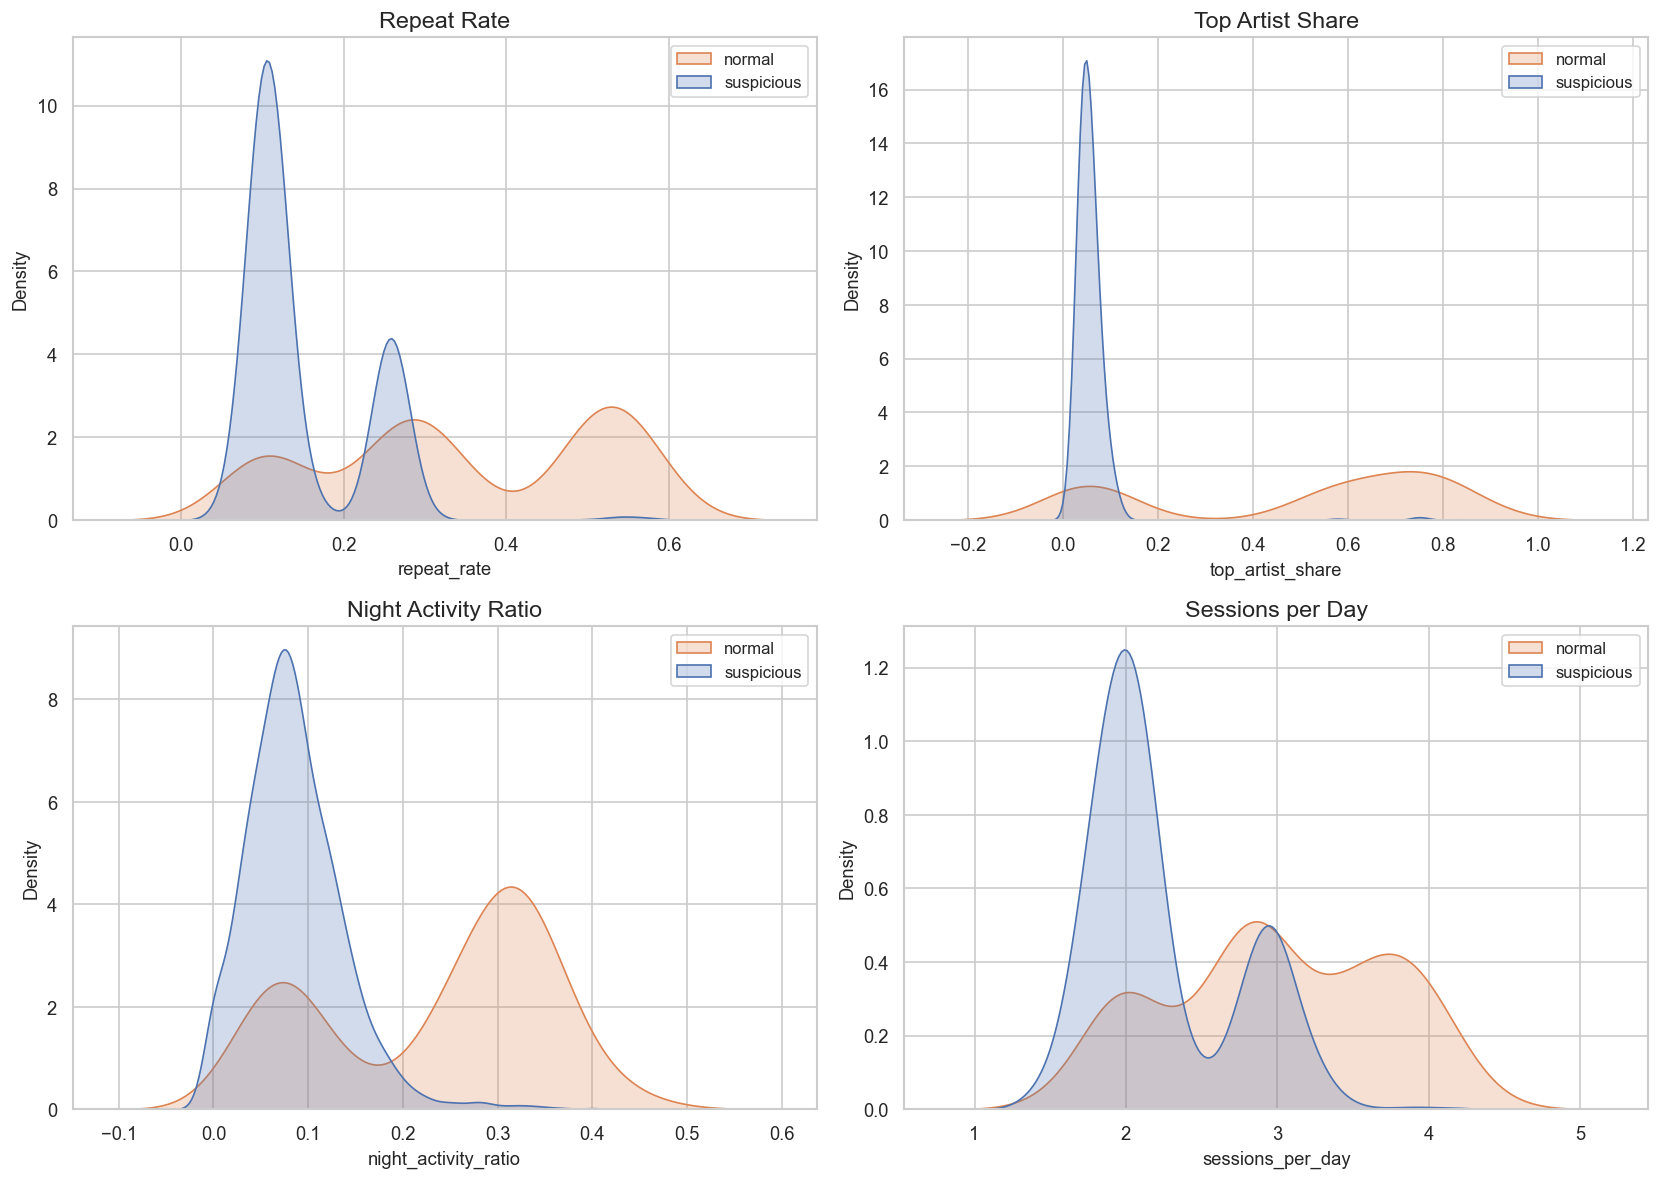

In [4]:
segment_summary = (
    user_features.groupby('label_suspicious')
    .agg(
        accounts=('user_id', 'count'),
        avg_streams=('total_streams', 'mean'),
        median_repeat_rate=('repeat_rate', 'median'),
        median_top_artist_share=('top_artist_share', 'median'),
        median_night_activity=('night_activity_ratio', 'median'),
        median_sessions_per_day=('sessions_per_day', 'median'),
    )
    .rename(index={0: 'normal', 1: 'suspicious'})
)
display(segment_summary)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plot_columns = [
    ('repeat_rate', 'Repeat Rate'),
    ('top_artist_share', 'Top Artist Share'),
    ('night_activity_ratio', 'Night Activity Ratio'),
    ('sessions_per_day', 'Sessions per Day'),
]
for ax, (column, title) in zip(axes.flatten(), plot_columns):
    sns.kdeplot(
        data=user_features,
        x=column,
        hue='label_suspicious',
        common_norm=False,
        fill=True,
        alpha=0.25,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel(column)
    ax.legend(['normal', 'suspicious'])

save_fig('user_behavior_distributions.png')
plt.show()

/var/folders/8x/r23r85f11p7f99bc2gq2kxwh0000gn/T/ipykernel_10452/173592710.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(['normal', 'suspicious'])


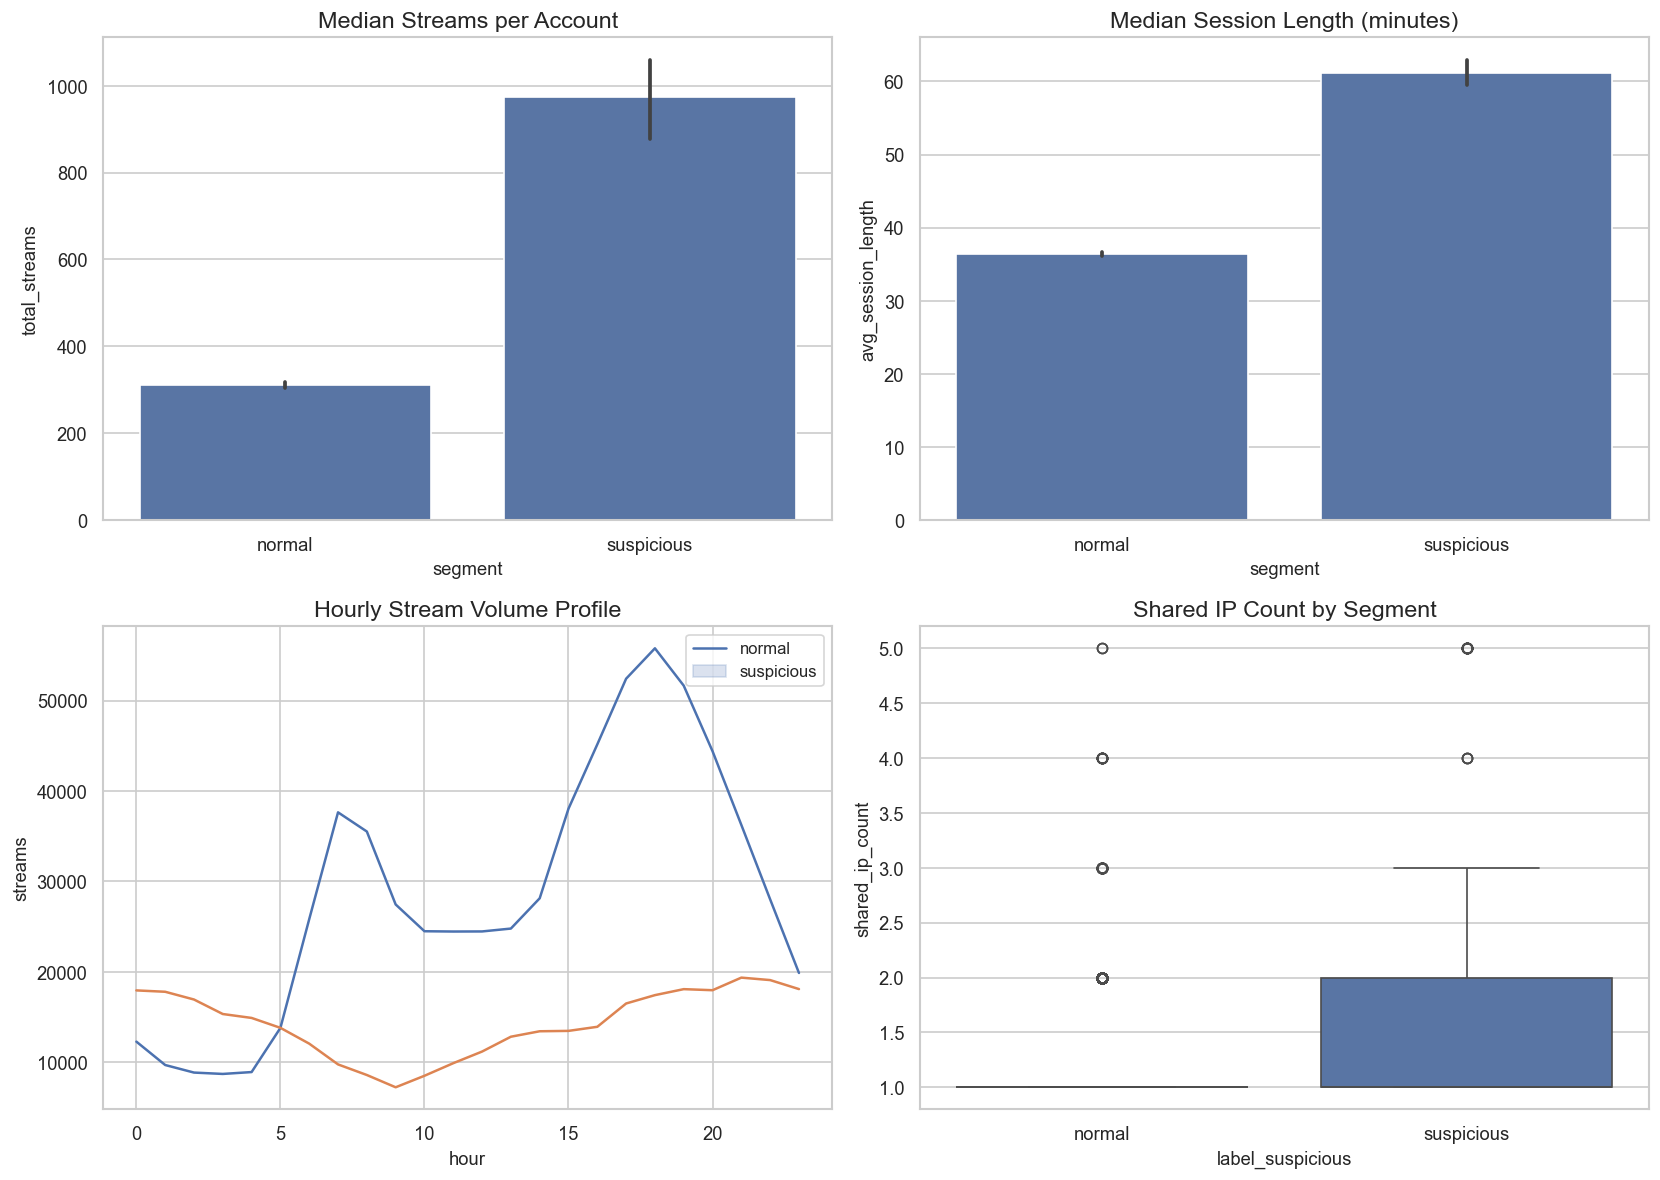

In [5]:
eda_hourly = events.copy()
eda_hourly['hour'] = eda_hourly['timestamp'].dt.hour
hourly_profile = (
    eda_hourly.groupby(['label_suspicious', 'hour'])
    .size()
    .reset_index(name='streams')
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.barplot(
    data=user_features.assign(segment=user_features['label_suspicious'].map({0: 'normal', 1: 'suspicious'})),
    x='segment',
    y='total_streams',
    estimator=np.median,
    ax=axes[0, 0],
)
axes[0, 0].set_title('Median Streams per Account')

sns.barplot(
    data=user_features.assign(segment=user_features['label_suspicious'].map({0: 'normal', 1: 'suspicious'})),
    x='segment',
    y='avg_session_length',
    estimator=np.median,
    ax=axes[0, 1],
)
axes[0, 1].set_title('Median Session Length (minutes)')

sns.lineplot(
    data=hourly_profile,
    x='hour',
    y='streams',
    hue='label_suspicious',
    ax=axes[1, 0],
)
axes[1, 0].set_title('Hourly Stream Volume Profile')
axes[1, 0].legend(['normal', 'suspicious'])

sns.boxplot(
    data=user_features,
    x='label_suspicious',
    y='shared_ip_count',
    ax=axes[1, 1],
)
axes[1, 1].set_title('Shared IP Count by Segment')
axes[1, 1].set_xticklabels(['normal', 'suspicious'])

save_fig('session_and_infrastructure_patterns.png')
plt.show()

## 3. Fraud and anomaly hypotheses

The EDA suggests several explicit hypotheses worth carrying into modeling:

1. **Accounts with extremely high same-song repetition are more likely to be suspicious.**
2. **High artist concentration can indicate coordinated artist boosting rather than organic fandom.**
3. **High overnight activity and compressed inter-stream gaps may indicate automation.**
4. **Accounts sharing device and IP infrastructure are more likely to belong to account farms, but these features should be treated cautiously because households can create legitimate overlap.**
5. **Heavy legitimate listeners create overlap, so no single rule is sufficient. A score-based model with review thresholds is more practical than a hard-coded rule engine.**

## 4. Feature engineering

The user-level feature table aggregates raw events into behavioral signals suited for anomaly detection and review triage. The most important engineered features include:

- cadence features such as `plays_per_hour`, `sessions_per_day`, and `burstiness_score`
- concentration features such as `top_artist_share`, `top_song_share`, and diversity ratios
- completion and repeat metrics such as `repeat_rate`, `completion_rate`, and `same_song_repeat_ratio`
- infrastructure features such as `device_sharing_score`, `ip_sharing_score`, `shared_device_count`, and `shared_ip_count`
- temporal features such as `night_activity_ratio`, `avg_inter_stream_gap_sec`, and `max_hourly_streams`

In [6]:
feature_snapshot = user_features[
    [
        'user_id',
        'total_streams',
        'plays_per_hour',
        'repeat_rate',
        'completion_rate',
        'skip_rate',
        'artist_diversity',
        'song_diversity',
        'top_artist_share',
        'top_song_share',
        'night_activity_ratio',
        'burstiness_score',
        'device_sharing_score',
        'ip_sharing_score',
        'label_suspicious',
    ]
]
display(feature_snapshot.head(10))

comparison_columns = [
    'plays_per_hour',
    'repeat_rate',
    'completion_rate',
    'skip_rate',
    'top_artist_share',
    'top_song_share',
    'night_activity_ratio',
    'burstiness_score',
    'shared_device_count',
    'shared_ip_count',
]
feature_comparison = (
    user_features.groupby('label_suspicious')[comparison_columns]
    .median()
    .T
    .rename(columns={0: 'normal_median', 1: 'suspicious_median'})
    .sort_values('suspicious_median', ascending=False)
)
save_dataframe(feature_comparison.reset_index().rename(columns={'index': 'feature'}), TABLES_DIR / 'hypothesis_comparison.csv')
display(feature_comparison)

,user_id,total_streams,plays_per_hour,repeat_rate,completion_rate,skip_rate,artist_diversity,song_diversity,top_artist_share,top_song_share,night_activity_ratio,burstiness_score,device_sharing_score,ip_sharing_score,label_suspicious
0,user_00001,721,1.431,0.223,0.386,0.004,0.123,0.291,0.090,0.021,0.053,1.790,0.333,0.279,0
1,user_00002,825,1.375,0.268,0.372,0.001,0.095,0.250,0.097,0.019,0.067,2.033,0.333,0.279,0
2,user_00003,228,0.633,0.110,0.232,0.013,0.430,0.789,0.035,0.018,0.057,1.697,0.333,0.279,1
3,user_00004,426,0.710,0.101,0.200,0.026,0.296,0.683,0.035,0.012,0.031,1.649,0.333,0.279,0
4,user_00005,146,0.676,0.116,0.178,0.034,0.486,0.808,0.062,0.034,0.041,2.086,0.333,0.279,0
5,user_00006,909,1.353,0.265,0.382,0.004,0.110,0.271,0.080,0.018,0.069,2.012,0.333,0.279,0
6,user_00007,378,0.630,0.108,0.233,0.013,0.315,0.688,0.048,0.016,0.177,2.102,0.333,0.279,0
7,user_00008,351,0.609,0.094,0.168,0.017,0.345,0.732,0.046,0.014,0.063,1.622,0.333,0.279,0
8,user_00009,636,1.395,0.247,0.363,0.006,0.126,0.390,0.058,0.016,0.193,2.219,0.333,0.279,0
9,user_00010,299,0.733,0.090,0.184,0.043,0.431,0.826,0.030,0.013,0.097,1.821,0.333,0.279,0


label_suspicious,normal_median,suspicious_median
burstiness_score,1.957,2.217
plays_per_hour,0.699,1.758
shared_device_count,1.000,1.000
shared_ip_count,1.000,1.000
top_artist_share,0.051,0.595
completion_rate,0.203,0.353
repeat_rate,0.115,0.310
night_activity_ratio,0.080,0.281
top_song_share,0.017,0.185
skip_rate,0.014,0.000


## 5. Modeling strategy

This project intentionally combines unsupervised and supervised approaches:

- **Isolation Forest** serves as the anomaly-first model when labels are noisy or incomplete.
- **Random Forest** provides a strong supervised baseline that can capture nonlinear interactions across behavioral and infrastructure features.
- **Logistic Regression** provides a more interpretable baseline and a useful calibration check.

The Random Forest is treated as the primary portfolio model because it balances predictive performance with operational simplicity.

In [7]:
model_outputs = train_model_suite(user_features=user_features, save_outputs=True, random_state=42)
scored_users = model_outputs['scored_users']
feature_importance = model_outputs['feature_importance']

evaluation_outputs = compile_evaluation_outputs(scored_users=scored_users, save_outputs=True)
metrics = evaluation_outputs['metrics']
business_metrics = evaluation_outputs['business_metrics']
threshold_tradeoffs = evaluation_outputs['threshold_tradeoffs']

display(metrics)
display(business_metrics)

,model,precision,recall,f1,roc_auc,pr_auc
1,random_forest,0.934,0.704,0.803,0.833,0.724
2,logistic_regression,0.851,0.704,0.770,0.833,0.741
0,isolation_forest,0.663,0.704,0.683,0.834,0.749


,model,review_load_pct_accounts,review_load_pct_streams,suspicious_stream_capture,false_positive_rate_legit_users
0,isolation_forest,0.172,0.367,0.881,0.069
1,random_forest,0.122,0.325,0.881,0.010
2,logistic_regression,0.134,0.340,0.881,0.024


## 6. Evaluation

Model quality should be judged both statistically and operationally. Precision, recall, F1, ROC-AUC, and PR-AUC help compare ranking and classification quality, but product teams also need to know:

- what share of suspicious stream volume would be captured
- how many legitimate users would be incorrectly flagged
- what moderation review load a given threshold would create

/Users/trshwetha7/Desktop/Spotify/spotify_streaming_integrity/.venv/lib/python3.12/site-packages/sklearn/utils/_plotting.py:440: FutureWarning: y_pred was deprecated in 1.8 and will be removed in 1.10. Please use `y_score` instead.
  warnings.warn(


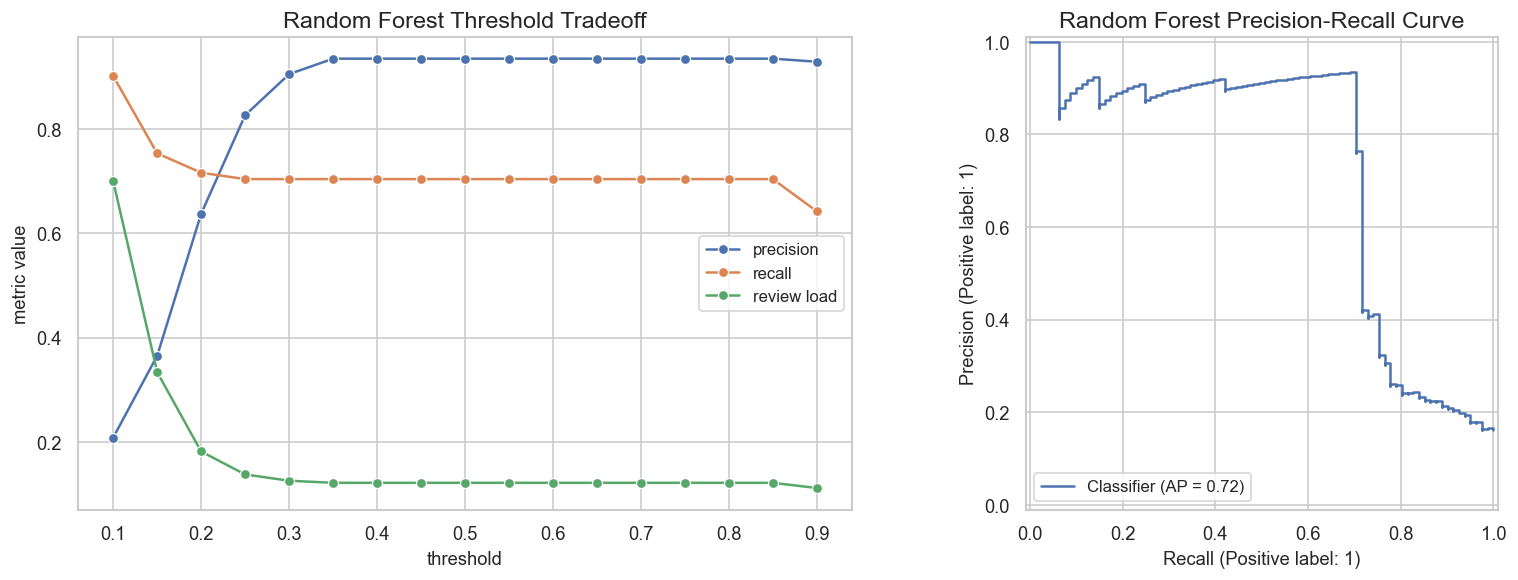

random_forest


,predicted_normal,predicted_suspicious
actual_normal,415,4
actual_suspicious,24,57


logistic_regression


,predicted_normal,predicted_suspicious
actual_normal,409,10
actual_suspicious,24,57


isolation_forest


,predicted_normal,predicted_suspicious
actual_normal,390,29
actual_suspicious,24,57


In [8]:
primary_model = 'random_forest'
primary_test = scored_users.loc[scored_users['split'] == 'test'].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=threshold_tradeoffs, x='threshold', y='precision', marker='o', ax=axes[0], label='precision')
sns.lineplot(data=threshold_tradeoffs, x='threshold', y='recall', marker='o', ax=axes[0], label='recall')
sns.lineplot(data=threshold_tradeoffs, x='threshold', y='review_load_pct_accounts', marker='o', ax=axes[0], label='review load')
axes[0].set_title('Random Forest Threshold Tradeoff')
axes[0].set_ylabel('metric value')

PrecisionRecallDisplay.from_predictions(
    y_true=primary_test['label_suspicious'],
    y_pred=primary_test['random_forest_score'],
    ax=axes[1],
)
axes[1].set_title('Random Forest Precision-Recall Curve')

save_fig('evaluation_tradeoffs.png')
plt.show()

for model_name in ['random_forest', 'logistic_regression', 'isolation_forest']:
    print(model_name)
    display(confusion_matrix_table(scored_users, model_name=model_name))

From an operations perspective, the supervised model is useful when the platform has a working label pipeline, while the anomaly model remains valuable for surfacing emerging behaviors that the current labeling taxonomy may miss.

## 7. Interpretation

The interpretation goal is to explain *why* a user is risky, not only *whether* they were flagged. In this project, feature importance is derived from Random Forest importance and permutation importance, while logistic coefficients provide a directional baseline for comparison.

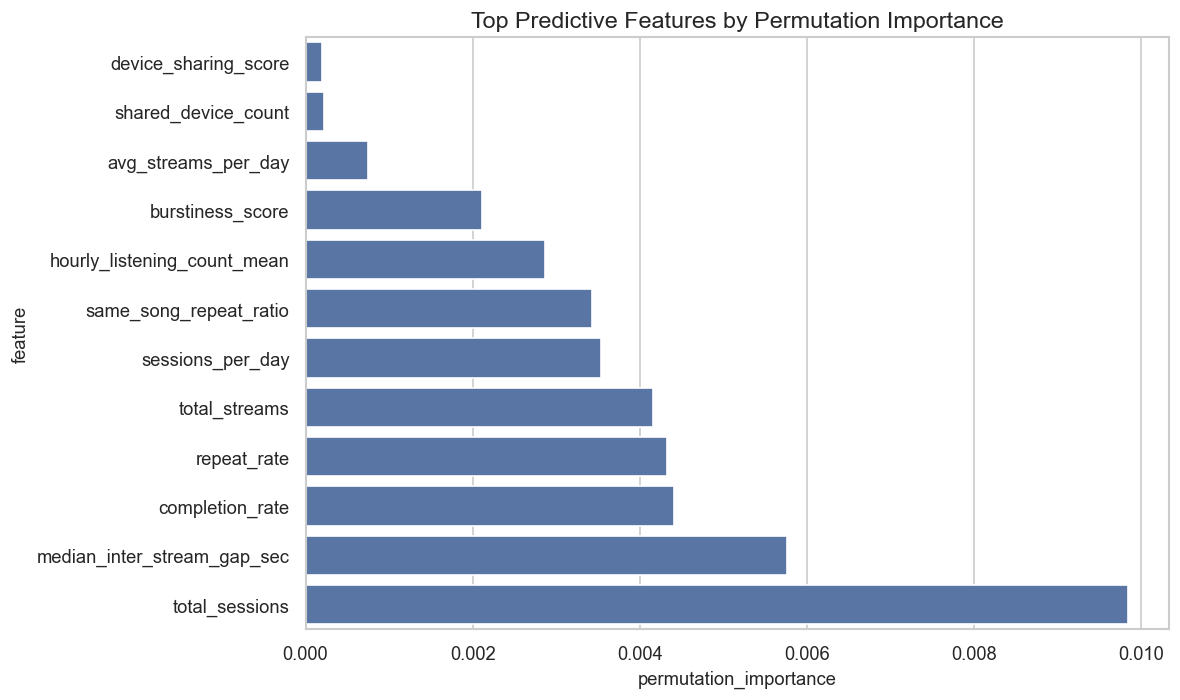

,feature,random_forest_importance,permutation_importance,logistic_coefficient,abs_logistic_coefficient
2,total_sessions,0.008,0.010,-0.336,0.336
21,median_inter_stream_gap_sec,0.014,0.006,0.244,0.244
7,completion_rate,0.019,0.004,0.134,0.134
6,repeat_rate,0.014,0.004,-0.030,0.030
1,total_streams,0.010,0.004,-0.377,0.377
17,sessions_per_day,0.010,0.004,0.444,0.444
22,same_song_repeat_ratio,0.015,0.003,-0.030,0.030
33,hourly_listening_count_mean,0.015,0.003,-0.413,0.413
19,burstiness_score,0.012,0.002,-0.078,0.078
4,avg_streams_per_day,0.015,0.001,-0.507,0.507


In [9]:
importance_plot = feature_importance.head(12).sort_values('permutation_importance')

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_plot, x='permutation_importance', y='feature', color='#4c72b0')
plt.title('Top Predictive Features by Permutation Importance')
save_fig('feature_importance.png')
plt.show()

display(feature_importance.head(12))

Typical drivers of high suspicious scores in this simulation include a combination of extreme repetition, concentration on a single artist or song, elevated overnight behavior, compressed stream gaps, and shared infrastructure. Importantly, the model works best when these features reinforce each other; that reduces the chance of over-penalizing benign superfans based on one metric alone.

## 8. Error analysis

False positives and false negatives matter because the cost of intervention is asymmetric:

- **False positives** can hurt legitimate users and artists, especially power users who naturally have concentrated listening habits.
- **False negatives** allow coordinated manipulation to remain in rankings and royalty calculations.

The error analysis below focuses on Random Forest because it is the primary supervised model for this portfolio project.

In [10]:
rf_test = scored_users.loc[scored_users['split'] == 'test'].copy()
false_positives = rf_test.query('label_suspicious == 0 and random_forest_pred == 1').copy()
false_negatives = rf_test.query('label_suspicious == 1 and random_forest_pred == 0').copy()
true_positives = rf_test.query('label_suspicious == 1 and random_forest_pred == 1').copy()

error_columns = [
    'user_id',
    'random_forest_score',
    'repeat_rate',
    'top_artist_share',
    'top_song_share',
    'night_activity_ratio',
    'burstiness_score',
    'shared_ip_count',
    'shared_device_count',
    'plays_per_hour',
]

print('False positives')
display(false_positives[error_columns].sort_values('random_forest_score', ascending=False).head(10))
print('False negatives')
display(false_negatives[error_columns].sort_values('random_forest_score').head(10))

error_summary = pd.DataFrame(
    {
        'false_positive_mean': false_positives[comparison_columns].mean(),
        'false_negative_mean': false_negatives[comparison_columns].mean(),
        'true_positive_mean': true_positives[comparison_columns].mean(),
    }
)
save_dataframe(error_summary.reset_index().rename(columns={'index': 'feature'}), TABLES_DIR / 'error_analysis_summary.csv')
display(error_summary)

False positives


,user_id,random_forest_score,repeat_rate,top_artist_share,top_song_share,night_activity_ratio,burstiness_score,shared_ip_count,shared_device_count,plays_per_hour
1822,user_01823,0.995,0.558,0.738,0.353,0.341,2.968,4,1,2.798
1146,user_01147,0.986,0.523,0.772,0.253,0.279,2.219,1,1,3.215
353,user_00354,0.976,0.540,0.746,0.352,0.231,2.151,1,1,3.027
1398,user_01399,0.961,0.551,0.753,0.354,0.251,2.109,1,1,2.475


False negatives


,user_id,random_forest_score,repeat_rate,top_artist_share,top_song_share,night_activity_ratio,burstiness_score,shared_ip_count,shared_device_count,plays_per_hour
569,user_00570,0.056,0.140,0.039,0.013,0.073,2.099,1,1,0.668
869,user_00870,0.057,0.098,0.030,0.017,0.064,2.409,1,1,0.685
906,user_00907,0.078,0.095,0.040,0.015,0.105,1.991,1,1,0.694
489,user_00490,0.078,0.251,0.054,0.015,0.078,2.123,1,1,1.403
1741,user_01742,0.090,0.259,0.049,0.014,0.084,1.911,1,1,1.472
27,user_00028,0.095,0.082,0.060,0.015,0.127,1.714,1,1,0.657
141,user_00142,0.097,0.092,0.046,0.020,0.072,1.930,1,1,0.637
1796,user_01797,0.100,0.227,0.056,0.013,0.068,2.231,1,1,1.395
1886,user_01887,0.102,0.102,0.042,0.013,0.093,1.930,1,1,0.656
1387,user_01388,0.107,0.087,0.043,0.029,0.167,1.743,1,1,0.575


,false_positive_mean,false_negative_mean,true_positive_mean
plays_per_hour,2.879,0.915,2.566
repeat_rate,0.543,0.160,0.453
completion_rate,0.594,0.246,0.499
skip_rate,0.000,0.014,0.000
top_artist_share,0.752,0.052,0.705
top_song_share,0.328,0.018,0.243
night_activity_ratio,0.275,0.086,0.311
burstiness_score,2.362,1.968,2.342
shared_device_count,1.000,1.000,1.228
shared_ip_count,1.750,1.083,2.000


### Error analysis interpretation

A typical false positive in this setting looks like a highly engaged fan account with strong artist concentration and above-average session intensity, but without the full suspicious profile. False negatives tend to be stealthier suspicious accounts that mimic normal completion and session cadence while still engaging in coordinated boosting behavior. This is where network signals, account-linkage features, or sequence models would likely add incremental lift.

## 9. Business recommendations

1. **Use a tiered enforcement strategy.** Treat the model as a triage layer rather than an automatic ban engine. High-risk accounts can be soft-flagged first, then escalated to manual review or downstream enforcement workflows.
2. **Tune thresholds to moderation capacity.** The threshold tradeoff curve shows that review load changes materially with threshold choice. A platform should pick thresholds based on team capacity and the acceptable false positive rate for legitimate fans.
3. **Prioritize suspicious stream capture, not only account recall.** Capturing the stream volume attached to suspicious accounts is operationally important because it directly affects rankings and royalty integrity.
4. **Separate product signals from enforcement decisions.** Features like shared IPs are useful triage signals, but they should be combined with behavioral evidence before taking hard action because households and shared networks can create benign overlap.
5. **Monitor model drift continuously.** Suspicious actors adapt. A model monitoring layer should track shifts in repetition, concentration, device sharing, and overnight activity over time.

## 10. Limitations

- The project uses synthetic data, so real-world behavioral nuance and adversarial adaptation will be more complex.
- Labels are simulated and intentionally noisy; they do not replace real investigation outcomes.
- The current feature set is mostly account-centric and does not include richer graph or network structure.
- Geographic, device, and subscription signals should be reviewed carefully to avoid proxying for legitimate user segments in unfair ways.
- The anomaly model is useful for surfacing outliers, but unsupervised detection alone is rarely enough for policy decisions.

## 11. Next steps

- Add graph-based detection over account, artist, IP, and device networks.
- Incorporate sequence modeling for repeated looping and session-path behavior.
- Add reviewer outcomes or intervention labels to calibrate decision thresholds more precisely.
- Estimate downstream business impact on charts, royalties, recommendations, and creator fairness.
- Design experiments for soft interventions such as cooldowns, streaming friction, or ranking suppression before hard enforcement.